# Variational Autoencoder I: Training

## General configuration

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchsummary import summary

import xarray as xr
import matplotlib.pyplot as plt

from helper import MinMaxScale, EnsembleDataset, VariationalAutoencoder, VAELoss

In [14]:
### Configuration ###
BATCH_SIZE    = 12
LATENT_DIM    = 10
LEARNING_RATE = 1E-3
NUM_EPOCHS    = 150
RANDOM_SEED   = 23 #42
FNAME_MODEL   = 'vae.pt'

## Main functions

In [15]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        optimizer.zero_grad()
        prediction, mu, logvar = model(batch)
        loss = criterion(prediction,batch,mu,logvar)
        loss.backward()
        optimizer.step()
        
        # Get current batch size
        current_batch_size = batch.size(0)
        total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

In [16]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            prediction, mu, logvar = model(batch)
            loss = criterion(prediction,batch,mu,logvar)

            # Get current batch size
            current_batch_size = batch.size(0)
            total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

## 1. Loading raw data

In [17]:
fname = 'data/tephra_col_mass.nc'
ds = xr.open_dataset(fname)
da = ds["tephra_col_mass"]

## 2. Create a custom Dataset and splitting

In [18]:
transform = MinMaxScale(0, 25)
dataset = EnsembleDataset(da, transform)

# Random split with in training and validation datasets
n_total = len(dataset)
n_train = int(0.8 * n_total)   # 80% train
n_val   = n_total - n_train    # 20% val

torch.manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(dataset, [n_train, n_val])

## 3. Create a DataLoader

In [19]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. Define a model

In [20]:
model = VariationalAutoencoder(LATENT_DIM)
summary(model, (1,101,121))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 51, 61]             160
              ReLU-2           [-1, 16, 51, 61]               0
            Conv2d-3           [-1, 32, 26, 31]           4,640
              ReLU-4           [-1, 32, 26, 31]               0
            Conv2d-5           [-1, 64, 13, 16]          18,496
              ReLU-6           [-1, 64, 13, 16]               0
           Flatten-7                [-1, 13312]               0
            Linear-8                   [-1, 10]         133,130
            Linear-9                   [-1, 10]         133,130
           Linear-10                [-1, 13312]         146,432
             ReLU-11                [-1, 13312]               0
        Unflatten-12           [-1, 64, 13, 16]               0
  ConvTranspose2d-13           [-1, 32, 26, 31]          18,464
             ReLU-14           [-1, 32,

## 5. Loss function

In [21]:
criterion = VAELoss(beta=4.0)

## 6. Optimizer

In [22]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training loop

In [23]:
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    # Store current losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch%10 == 0 or epoch == NUM_EPOCHS-1:
        print(f"Epoch {epoch+1:02d} -> Train loss {train_loss:.4f} | Validation loss: {val_loss:.4f}")
print("Done!")

Epoch 01 -> Train loss 859.2134 | Validation loss: 763.2646
Epoch 11 -> Train loss 223.8211 | Validation loss: 170.9283
Epoch 21 -> Train loss 96.8064 | Validation loss: 117.9885
Epoch 31 -> Train loss 67.7146 | Validation loss: 66.3818
Epoch 41 -> Train loss 58.3659 | Validation loss: 54.1472
Epoch 51 -> Train loss 54.3369 | Validation loss: 54.0545
Epoch 61 -> Train loss 49.6040 | Validation loss: 50.8524
Epoch 71 -> Train loss 46.6791 | Validation loss: 43.5052
Epoch 81 -> Train loss 42.9709 | Validation loss: 42.8932
Epoch 91 -> Train loss 43.1133 | Validation loss: 40.6733
Epoch 101 -> Train loss 41.6972 | Validation loss: 40.0486
Epoch 111 -> Train loss 39.5609 | Validation loss: 38.1696
Epoch 121 -> Train loss 38.7797 | Validation loss: 37.2102
Epoch 131 -> Train loss 38.6719 | Validation loss: 37.8611
Epoch 141 -> Train loss 36.7882 | Validation loss: 35.0443
Epoch 150 -> Train loss 38.0856 | Validation loss: 37.9955
Done!


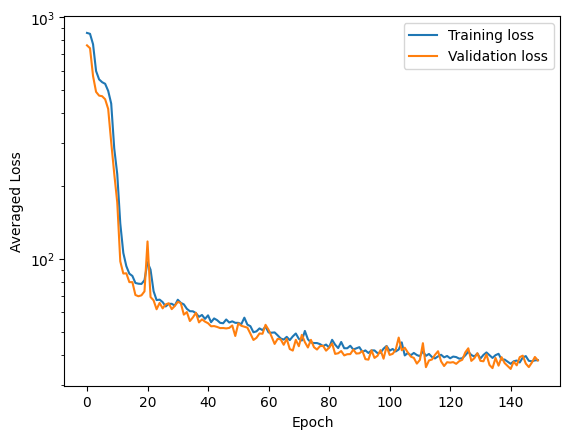

In [24]:
plt.plot(train_losses, label = 'Training loss')
plt.plot(val_losses, label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Averaged Loss')
plt.legend()
plt.yscale('log')

## Save trained model

In [25]:
torch.save(model.state_dict(), FNAME_MODEL)